In [37]:
import os
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

In [38]:
path = kagglehub.dataset_download('krishnaraj30/salary-prediction-data-simple-linear-regression')

file_path = os.path.join(path, 'Salary_Data.csv')
df = pd.read_csv(file_path)

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


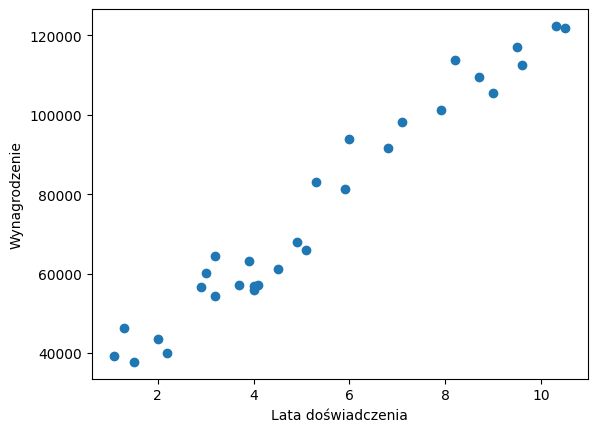

In [39]:
X_train = df['YearsExperience'].values
y_train = df['Salary'].values

plt.scatter(X_train, y_train)
plt.xlabel('Lata doświadczenia')
plt.ylabel('Wynagrodzenie')
plt.show()

In [40]:
def cost_function(x, y, w, b):
	m = len(x)
	cost_sum = 0

	for i in range(m):
		f = w * x[i] + b
		cost = (f - y[i]) ** 2
		cost_sum += cost
	
	total_cost = (1/(2*m)) * cost_sum
	return total_cost

def gradient_function(x, y, w, b):
	m = len(x)
	dw = 0
	db = 0

	for i in range(m):
		f = w * x[i] + b

		dw += (f - y[i]) * x[i]
		db += (f - y[i])

	dw = (1/m) * dw
	db = (1/m) * db

	return dw, db

In [41]:
def gradient_descent(x, y, learning_rate = 0.01, n_iterations = 1000):
	w = 0
	b = 0

	for i in range(n_iterations):
		dw, db = gradient_function(x, y, w, b)

		w = w - learning_rate * dw
		b = b - learning_rate * db

		print(f'Iteracja {i}: Koszt {cost_function(x, y, w, b)}')
	
	return w, b

In [ ]:
final_w, final_b = gradient_descent(X_train, y_train)
print(f'w: {final_w:.4f}, b: {final_b:.4f}')

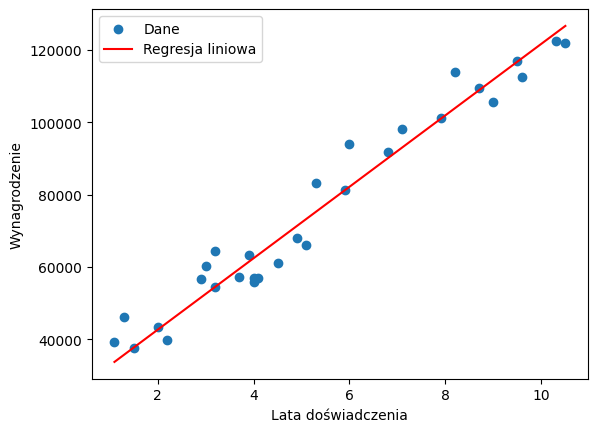

In [43]:
plt.scatter(X_train, y_train, label='Dane')
x_vals = np.linspace(min(X_train), max(X_train), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color='red', label='Regresja liniowa')
plt.xlabel("Lata doświadczenia")
plt.ylabel("Wynagrodzenie")
plt.legend()
plt.show()